# 📊 EDA & KPI Overview — A Day and a Half (Nordic Weekly Analysis) - Aira

🚀 Core KPI Framework
- weekly_views → demand (how many people watched)
- country_distribution → regional share (where demand comes from)
- weekly_trend → momentum (how performance evolves week-to-week)
- market_contribution → dominance (which country drives performance)

---
# 🎯 Analytical Scope
| Dimension         | Description                                  |
| ----------------- | -------------------------------------------- |
| **Geography**     | Sweden, Norway, Denmark, Finland, Iceland    |
| **Time Window**   | September 2023 (limited availability period) |
| **Grain**         | Country + Week                               |
| **Content Focus** | Single title: *A Day and a Half*             |
| **Constraint**    | Sparse data (short lifecycle, ~3 weeks)      |


----
# 📈 Possible Analytical Framework for UX

| Category                 | Grain          | KPI / Analysis             | What it Answers                           | Example Use    |
| ------------------------ | -------------- | -------------------------- | ----------------------------------------- | -------------- |
| **Data Scope**           | Country        | Available weeks, countries | What data do we actually have?            | Sanity check   |
| **Weekly Views Trend**   | Week           | SUM(weekly_hours_viewed)   | How did demand evolve over time?          | Line chart     |
| **Country Breakdown**    | Country        | SUM(weekly_hours_viewed)   | Which country watched the most?           | Bar chart      |
| **Market Share**         | Country        | % of total views           | How is demand distributed across Nordics? | Donut chart    |
| **Peak Performance**     | Week           | MAX(weekly_hours_viewed)   | When did the show peak?                   | Highlight KPI  |
| **Engagement Intensity** | Country + Week | weekly_hours_viewed        | Where and when was engagement strongest?  | Heatmap        |
| **Short-Term Momentum**  | Week           | Week-over-week change      | Is the show rising or declining?          | Trend analysis |
| **Regional Dominance**   | Country        | Rank by total views        | Which market leads consumption?           | Leaderboard    |
| **Volatility Analysis**  | Week           | Variance in views          | Is demand stable or fluctuating?          | Risk signal    |


In [3]:
import pandas as pd
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Resolve project root dynamically
BASE_DIR = Path().resolve()
while not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

# Paths
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

# Load global_alltime
df = pd.read_excel(DATA_RAW / "global_alltime.xlsx")

# Quick inspection
print(df.shape)
print(df.columns)
df.head()

# Register for duckdb.sql()
duckdb.register("global_alltime", df)

c:\Users\adelo\de25\Netflix_Analytics_DE_UX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(9840, 9)
Index(['week', 'category', 'weekly_rank', 'show_title', 'season_title',
       'weekly_hours_viewed', 'runtime', 'weekly_views',
       'cumulative_weeks_in_top_10'],
      dtype='object')


In [4]:
duckdb.sql("""
DESCRIBE global_alltime
""").df()

,column_name,column_type,null,key,default,extra
0,week,VARCHAR,YES,None,None,None
1,category,VARCHAR,YES,None,None,None
2,weekly_rank,BIGINT,YES,None,None,None
3,show_title,VARCHAR,YES,None,None,None
4,season_title,VARCHAR,YES,None,None,None
5,weekly_hours_viewed,BIGINT,YES,None,None,None
6,runtime,DOUBLE,YES,None,None,None
7,weekly_views,DOUBLE,YES,None,None,None
8,cumulative_weeks_in_top_10,BIGINT,YES,None,None,None


## Inspect DF and Tables
Same as other notebooks so this will be a shortcut.

In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9840 entries, 0 to 9839
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   week                        9840 non-null   object 
 1   category                    9840 non-null   object 
 2   weekly_rank                 9840 non-null   int64  
 3   show_title                  9840 non-null   object 
 4   season_title                4775 non-null   object 
 5   weekly_hours_viewed         9840 non-null   int64  
 6   runtime                     5760 non-null   float64
 7   weekly_views                5760 non-null   float64
 8   cumulative_weeks_in_top_10  9840 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 692.0+ KB


In [6]:
df.shape

(9840, 9)

In [7]:
df.head()

,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10
0,2026-03-15,Films (English),1,War Machine,NaN,80600000,1.8167,44400000.0,2
1,2026-03-15,Films (English),2,Louis Theroux: Inside the Manosphere,NaN,9600000,1.5167,6300000.0,1
2,2026-03-15,Films (English),3,Shark Tale,NaN,8100000,1.5000,5400000.0,2
3,2026-03-15,Films (English),4,KPop Demon Hunters,NaN,8800000,1.6667,5300000.0,39
4,2026-03-15,Films (English),5,Double Jeopardy,NaN,6200000,1.7667,3500000.0,1


## Convert Week to DateTime

In [8]:
df.dtypes

week                           object
category                       object
weekly_rank                     int64
show_title                     object
season_title                   object
weekly_hours_viewed             int64
runtime                       float64
weekly_views                  float64
cumulative_weeks_in_top_10      int64
dtype: object

In [9]:
# Keep everything as df
df["week"] = pd.to_datetime(df["week"])
df["year"] = df["week"].dt.year

In [10]:
# Register Table to DuckDB
duckdb.register("global_alltime", df)

## Exploratory Data Analysis on A Day and a Half
- Aggregate yearly views + hours for A Day and a Half
- Popularity Curve in its release

In [11]:
a_day_half_yearly = duckdb.sql("""
SELECT
    year,
    
    COUNT(*) AS appearances,
    
    SUM(COALESCE(weekly_views, 0)) AS total_views,
    SUM(weekly_hours_viewed) AS total_hours,
    
    ROUND(AVG(weekly_rank), 2) AS avg_rank

FROM global_alltime
WHERE LOWER(show_title) LIKE '%day%half%'

GROUP BY year
ORDER BY year
""").df()

a_day_half_yearly

,year,appearances,total_views,total_hours,avg_rank
0,2023,3,12500000.0,20000000.0,3.0


In [12]:
a_day_half_weekly = duckdb.sql("""
SELECT
    week,
    SUM(COALESCE(weekly_views, 0)) AS weekly_views
FROM global_alltime
WHERE LOWER(show_title) LIKE '%day%half%'
GROUP BY week
ORDER BY week
""").df()
a_day_half_weekly

,week,weekly_views
0,2023-09-03,4400000.0
1,2023-09-10,6500000.0
2,2023-09-17,1600000.0


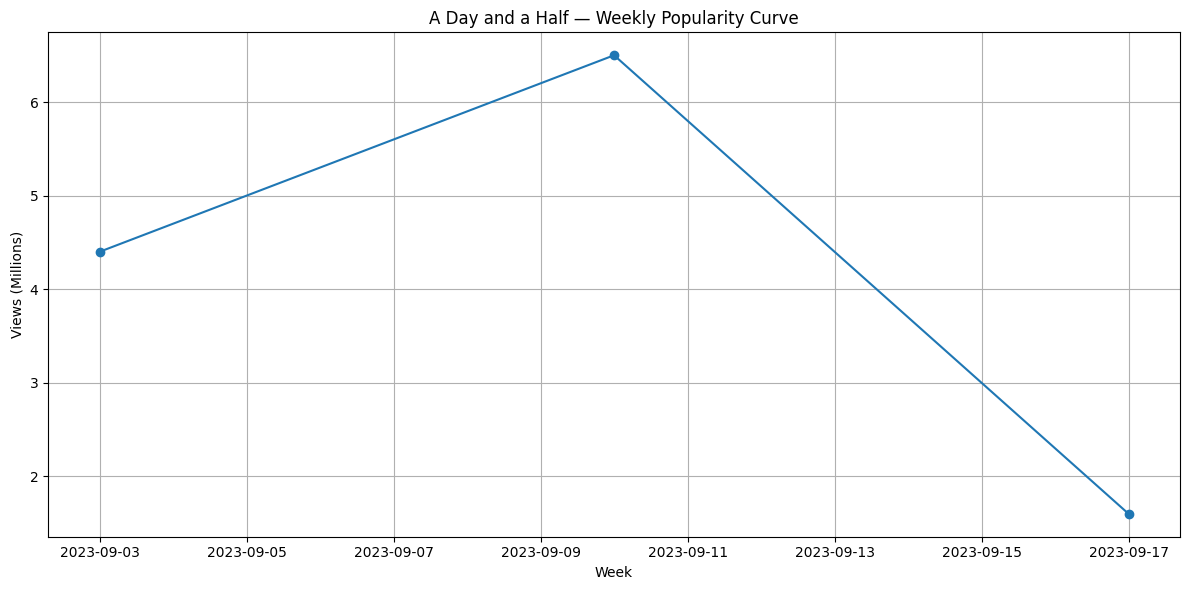

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    a_day_half_weekly["week"],
    a_day_half_weekly["weekly_views"] / 1_000_000,
    marker='o'
)

plt.title("A Day and a Half — Weekly Popularity Curve")
plt.xlabel("Week")
plt.ylabel("Views (Millions)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# Create a Year Table
years_df = pd.DataFrame({
    "year": [2021, 2022, 2023, 2024, 2025]
})

duckdb.register("years", years_df)

- Check the yearly views of A Day and a Half
- I see that this is a short lifecycle (only a few weeks)
- Only data visible for 2023 and for the month of September

In [15]:
a_day_half_yearly_full = duckdb.sql("""
WITH film_data AS (
    SELECT
        year,
        SUM(COALESCE(weekly_views, 0)) AS total_views
    FROM global_alltime
    WHERE LOWER(show_title) LIKE '%day%half%'
    GROUP BY year
)

SELECT
    y.year,
    COALESCE(f.total_views, 0) AS total_views

FROM years y
LEFT JOIN film_data f
    ON y.year = f.year

ORDER BY y.year
""").df()

a_day_half_yearly_full

,year,total_views
0,2021,0.0
1,2022,0.0
2,2023,12500000.0
3,2024,0.0
4,2025,0.0


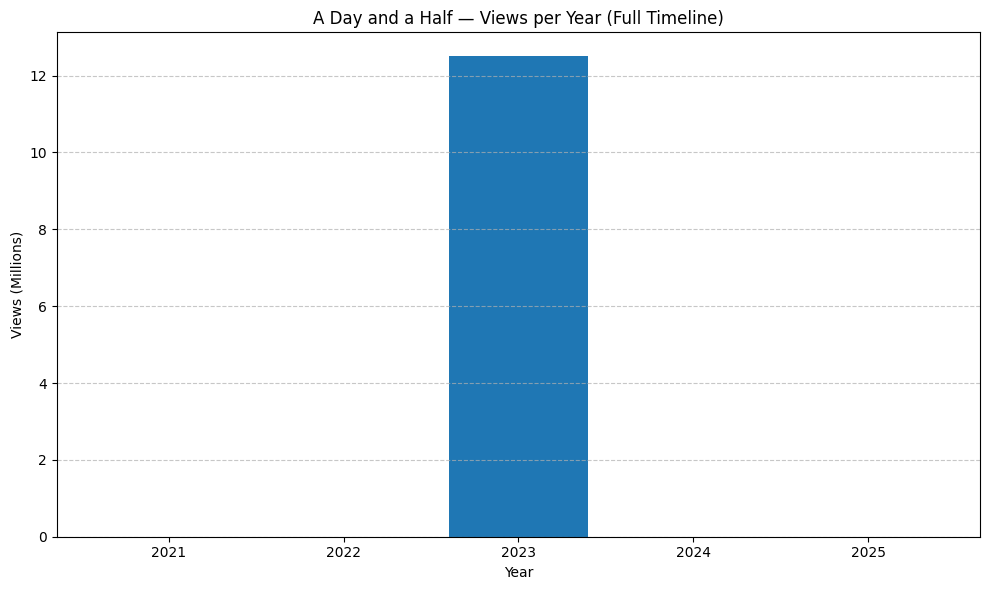

In [16]:
df_plot = a_day_half_yearly_full.copy()
df_plot["views_millions"] = df_plot["total_views"] / 1_000_000

plt.figure(figsize=(10,6))

bars = plt.bar(df_plot["year"], df_plot["views_millions"])

plt.title("A Day and a Half — Views per Year (Full Timeline)")
plt.xlabel("Year")
plt.ylabel("Views (Millions)")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

- Check the monthly views

In [17]:
# Create month df and register the month df
df["month"] = df["week"].dt.month
duckdb.register("global_alltime", df)

In [18]:
a_day_half_monthly = duckdb.sql("""
SELECT
    year,
    month,
    SUM(COALESCE(weekly_views, 0)) AS total_views
FROM global_alltime
WHERE LOWER(show_title) LIKE '%day%half%'
GROUP BY year, month
ORDER BY year, month
""").df()
a_day_half_monthly

,year,month,total_views
0,2023,9,12500000.0


# Filter only in the Nordics DF

In [19]:
nordics = ["Sweden", "Norway", "Denmark", "Finland", "Iceland"]

duckdb.register("nordics", pd.DataFrame({"country_name": nordics}))

### Weekly Only EDA

In [20]:
weekly_global = duckdb.sql("""
SELECT
    week,
    SUM(COALESCE(weekly_views, 0)) AS total_views
FROM global_alltime
WHERE LOWER(show_title) LIKE '%day%half%'
GROUP BY week
ORDER BY week
""").df()
weekly_global

,week,total_views
0,2023-09-03,4400000.0
1,2023-09-10,6500000.0
2,2023-09-17,1600000.0


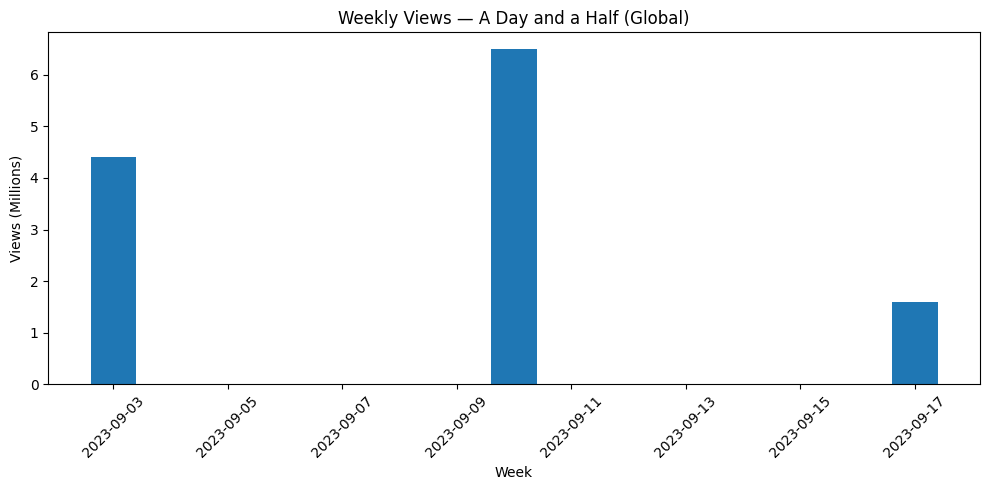

In [21]:
plt.figure(figsize=(10,5))

plt.bar(
    weekly_global["week"],
    weekly_global["total_views"] / 1_000_000
)

plt.title("Weekly Views — A Day and a Half (Global)")
plt.xlabel("Week")
plt.ylabel("Views (Millions)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()